In [1]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import models as mod
import utils

In [3]:
#utils.generate_linear_data("dataSets1")
X_train = pd.read_csv(f"dataSets/dataSets1/s4/train-x.csv", header = None)
y_train = pd.read_csv(f"dataSets/dataSets1/s4/train-y.csv", header = None)

X_test = pd.read_csv(f"dataSets/dataSets1/s4/test-x.csv", header = None)
y_test = pd.read_csv(f"dataSets/dataSets1/s4/test-y.csv", header = None)

features = pd.read_csv(f"dataSets/dataSets1/s4/important_inds.csv")
features = features.values.flatten()

In [4]:
model_with_ista = mod.AnnLassoRegression(name="Model with ISTA", warm_start=True)
model_without_ista = mod.AnnLassoRegression(name="Model without ISTA", warm_start=True, n_ista=-1)

In [5]:
model_with_ista.fit(X_train, y_train, print_epochs=False, set_name='test set')
model_without_ista.fit(X_train, y_train, print_epochs=False, set_name='test set')

Lambda path progress: 100%|██████████| 7/7 [03:02<00:00, 26.00s/it]


MODEL FITTED !


Lambda path progress: 100%|██████████| 7/7 [01:01<00:00,  8.72s/it]

MODEL FITTED !


In [6]:
model_with_ista.summary()

MODEL INFORMATIONS:
General:
――――――――――――――――――――
  Name: Model with ISTA
  Training Status: Trained
	 Training Time: 182.036 seconds
	 Training Set: test set
  Lambda_qut: 0.356

Layers:
――――――――――――――――――――
  Layer 1: 
	 Shape = [20, 200]
	 Number of non zero entries in weights: 4
	 Non zero entries indexes: [20, 45, 88, 150]
  Layer 2:
	 Shape = [1, 20]


In [7]:
model_without_ista.summary()

MODEL INFORMATIONS:
General:
――――――――――――――――――――
  Name: Model without ISTA
  Training Status: Trained
	 Training Time: 61.064 seconds
	 Training Set: test set
  Lambda_qut: 0.3558

Layers:
――――――――――――――――――――
  Layer 1: 
	 Shape = [20, 200]
	 Number of non zero entries in weights: 4
	 Non zero entries indexes: [20, 45, 88, 150]
  Layer 2:
	 Shape = [1, 20]


In [8]:
model_with_ista.results_analysis(X_test, y_test, features)

{'error': 23.428870049851778, 'TPR': 1.0, 'FDR': 0.0, 'exact_recovery': True}

In [9]:
model_without_ista.results_analysis(X_test, y_test, features)

{'error': 23.834595739747837, 'TPR': 1.0, 'FDR': 0.0, 'exact_recovery': True}

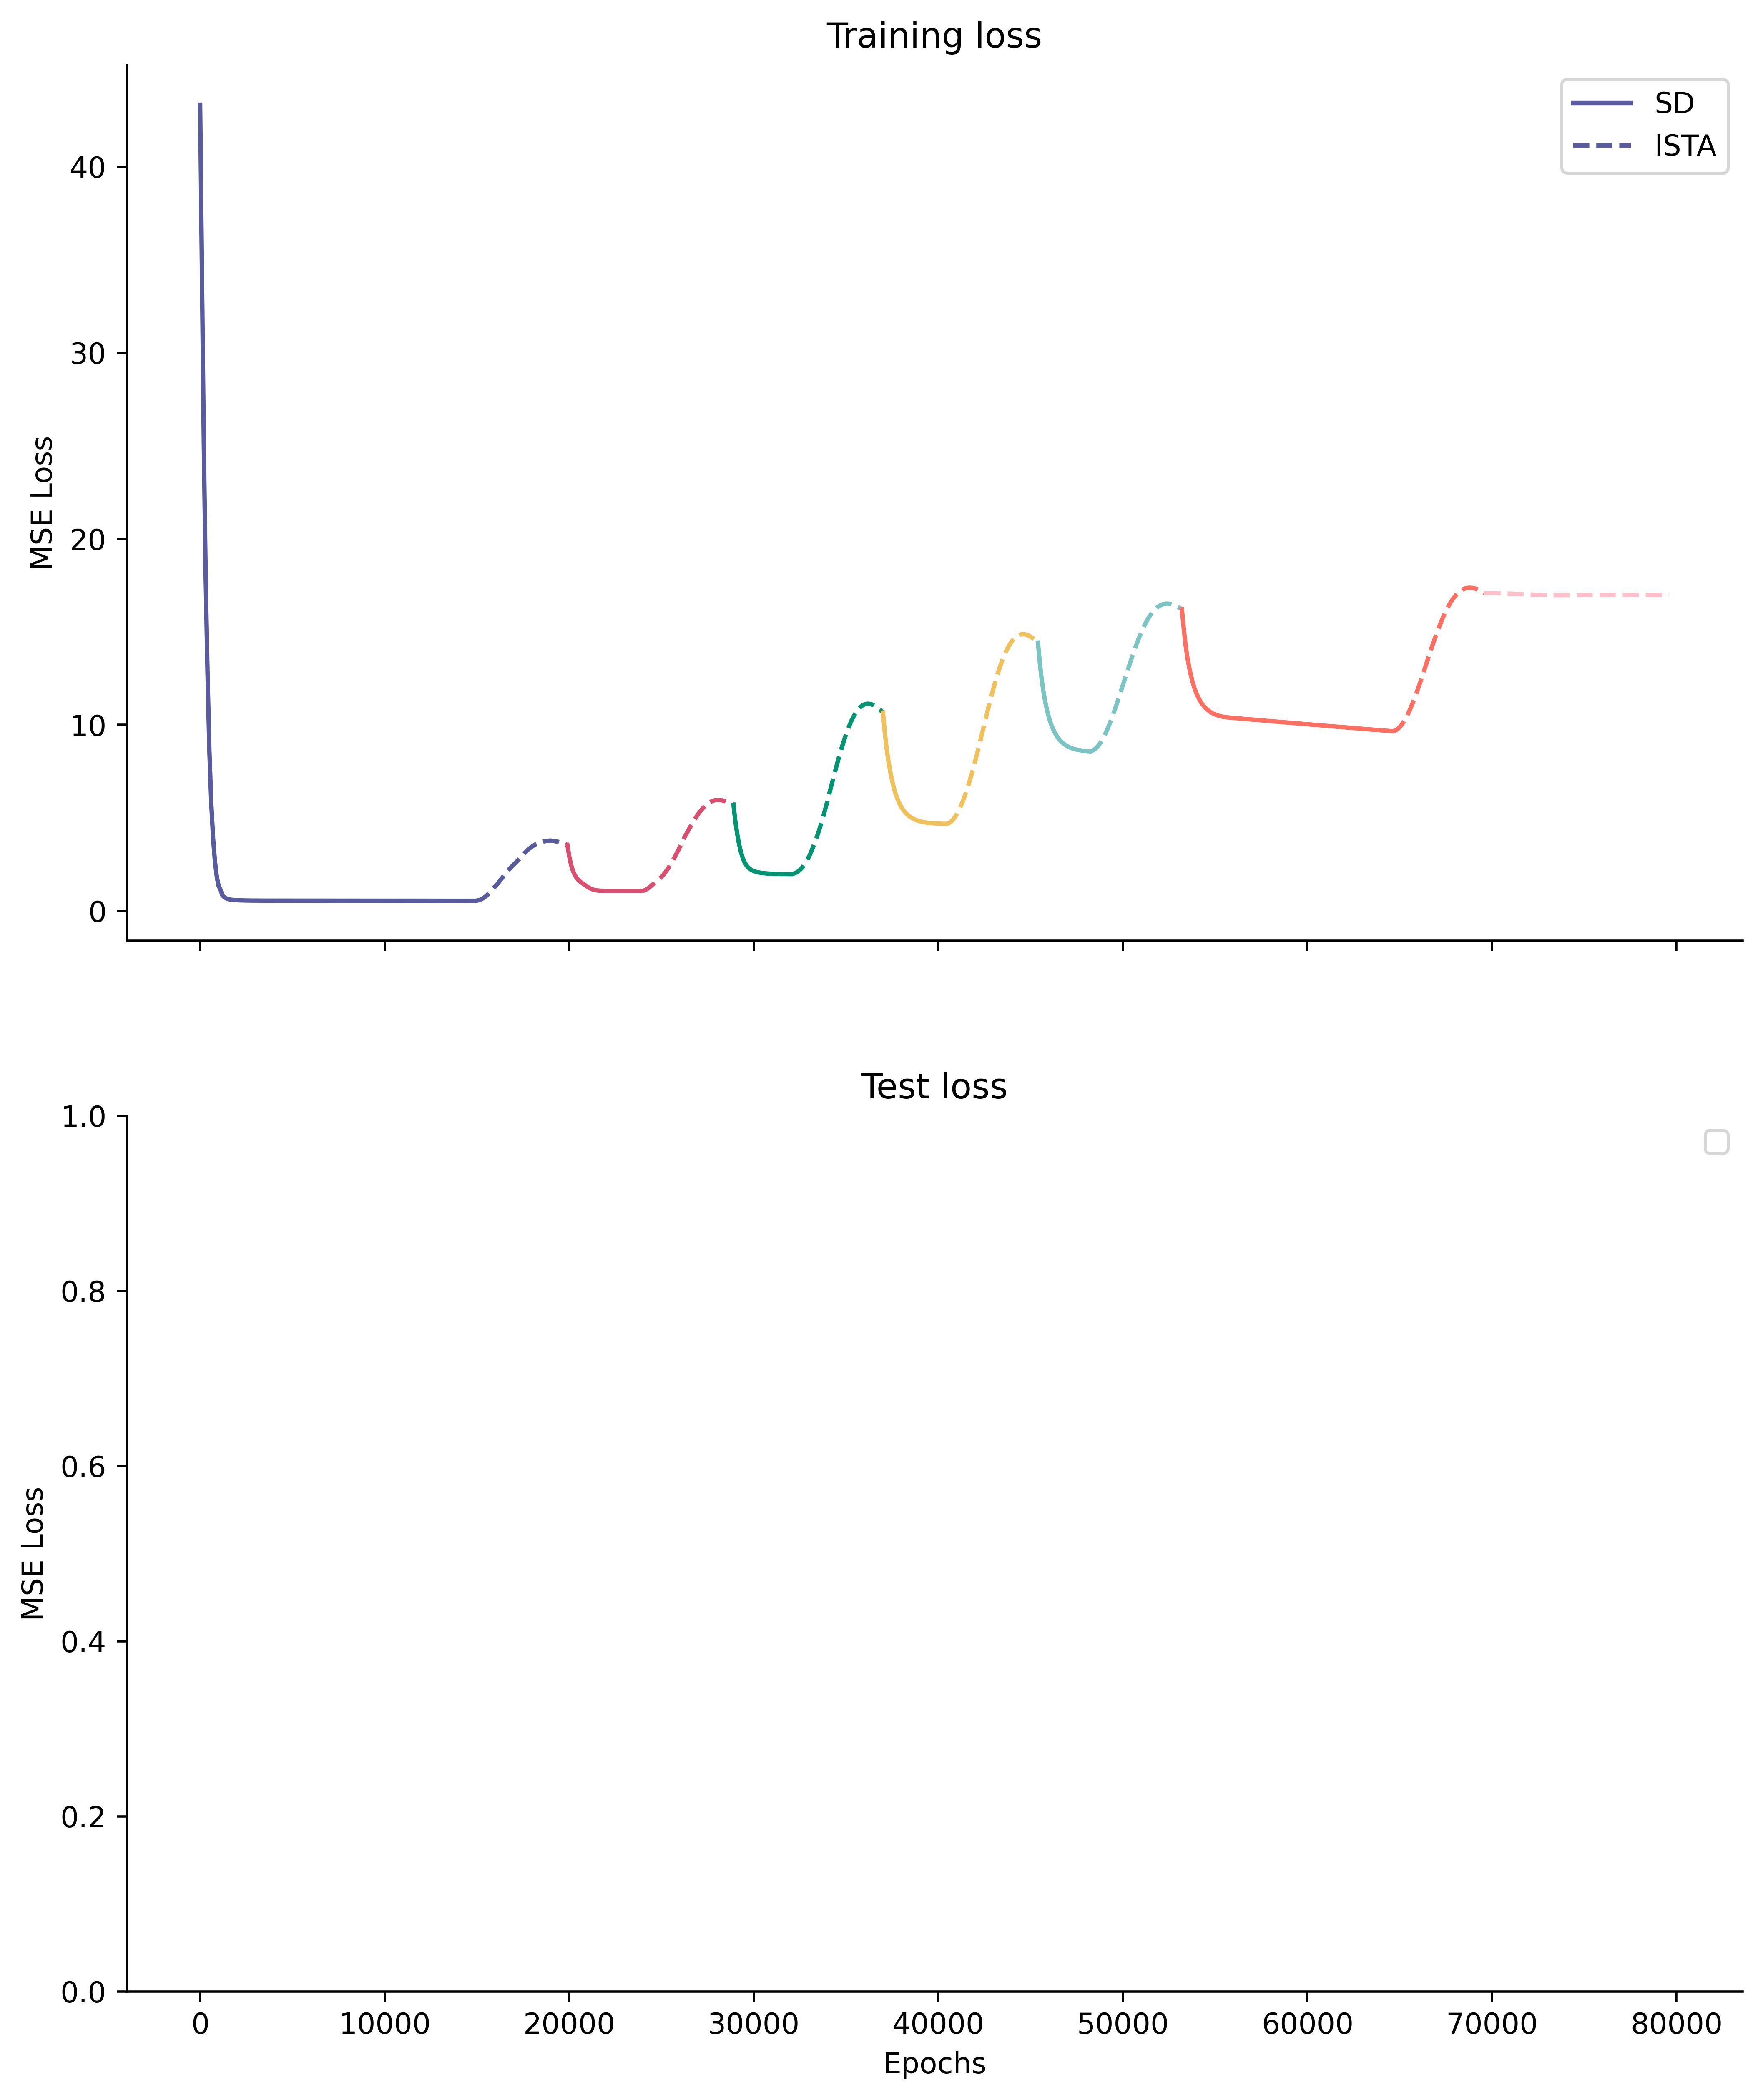

In [10]:
model_with_ista.plot_learning_curve()

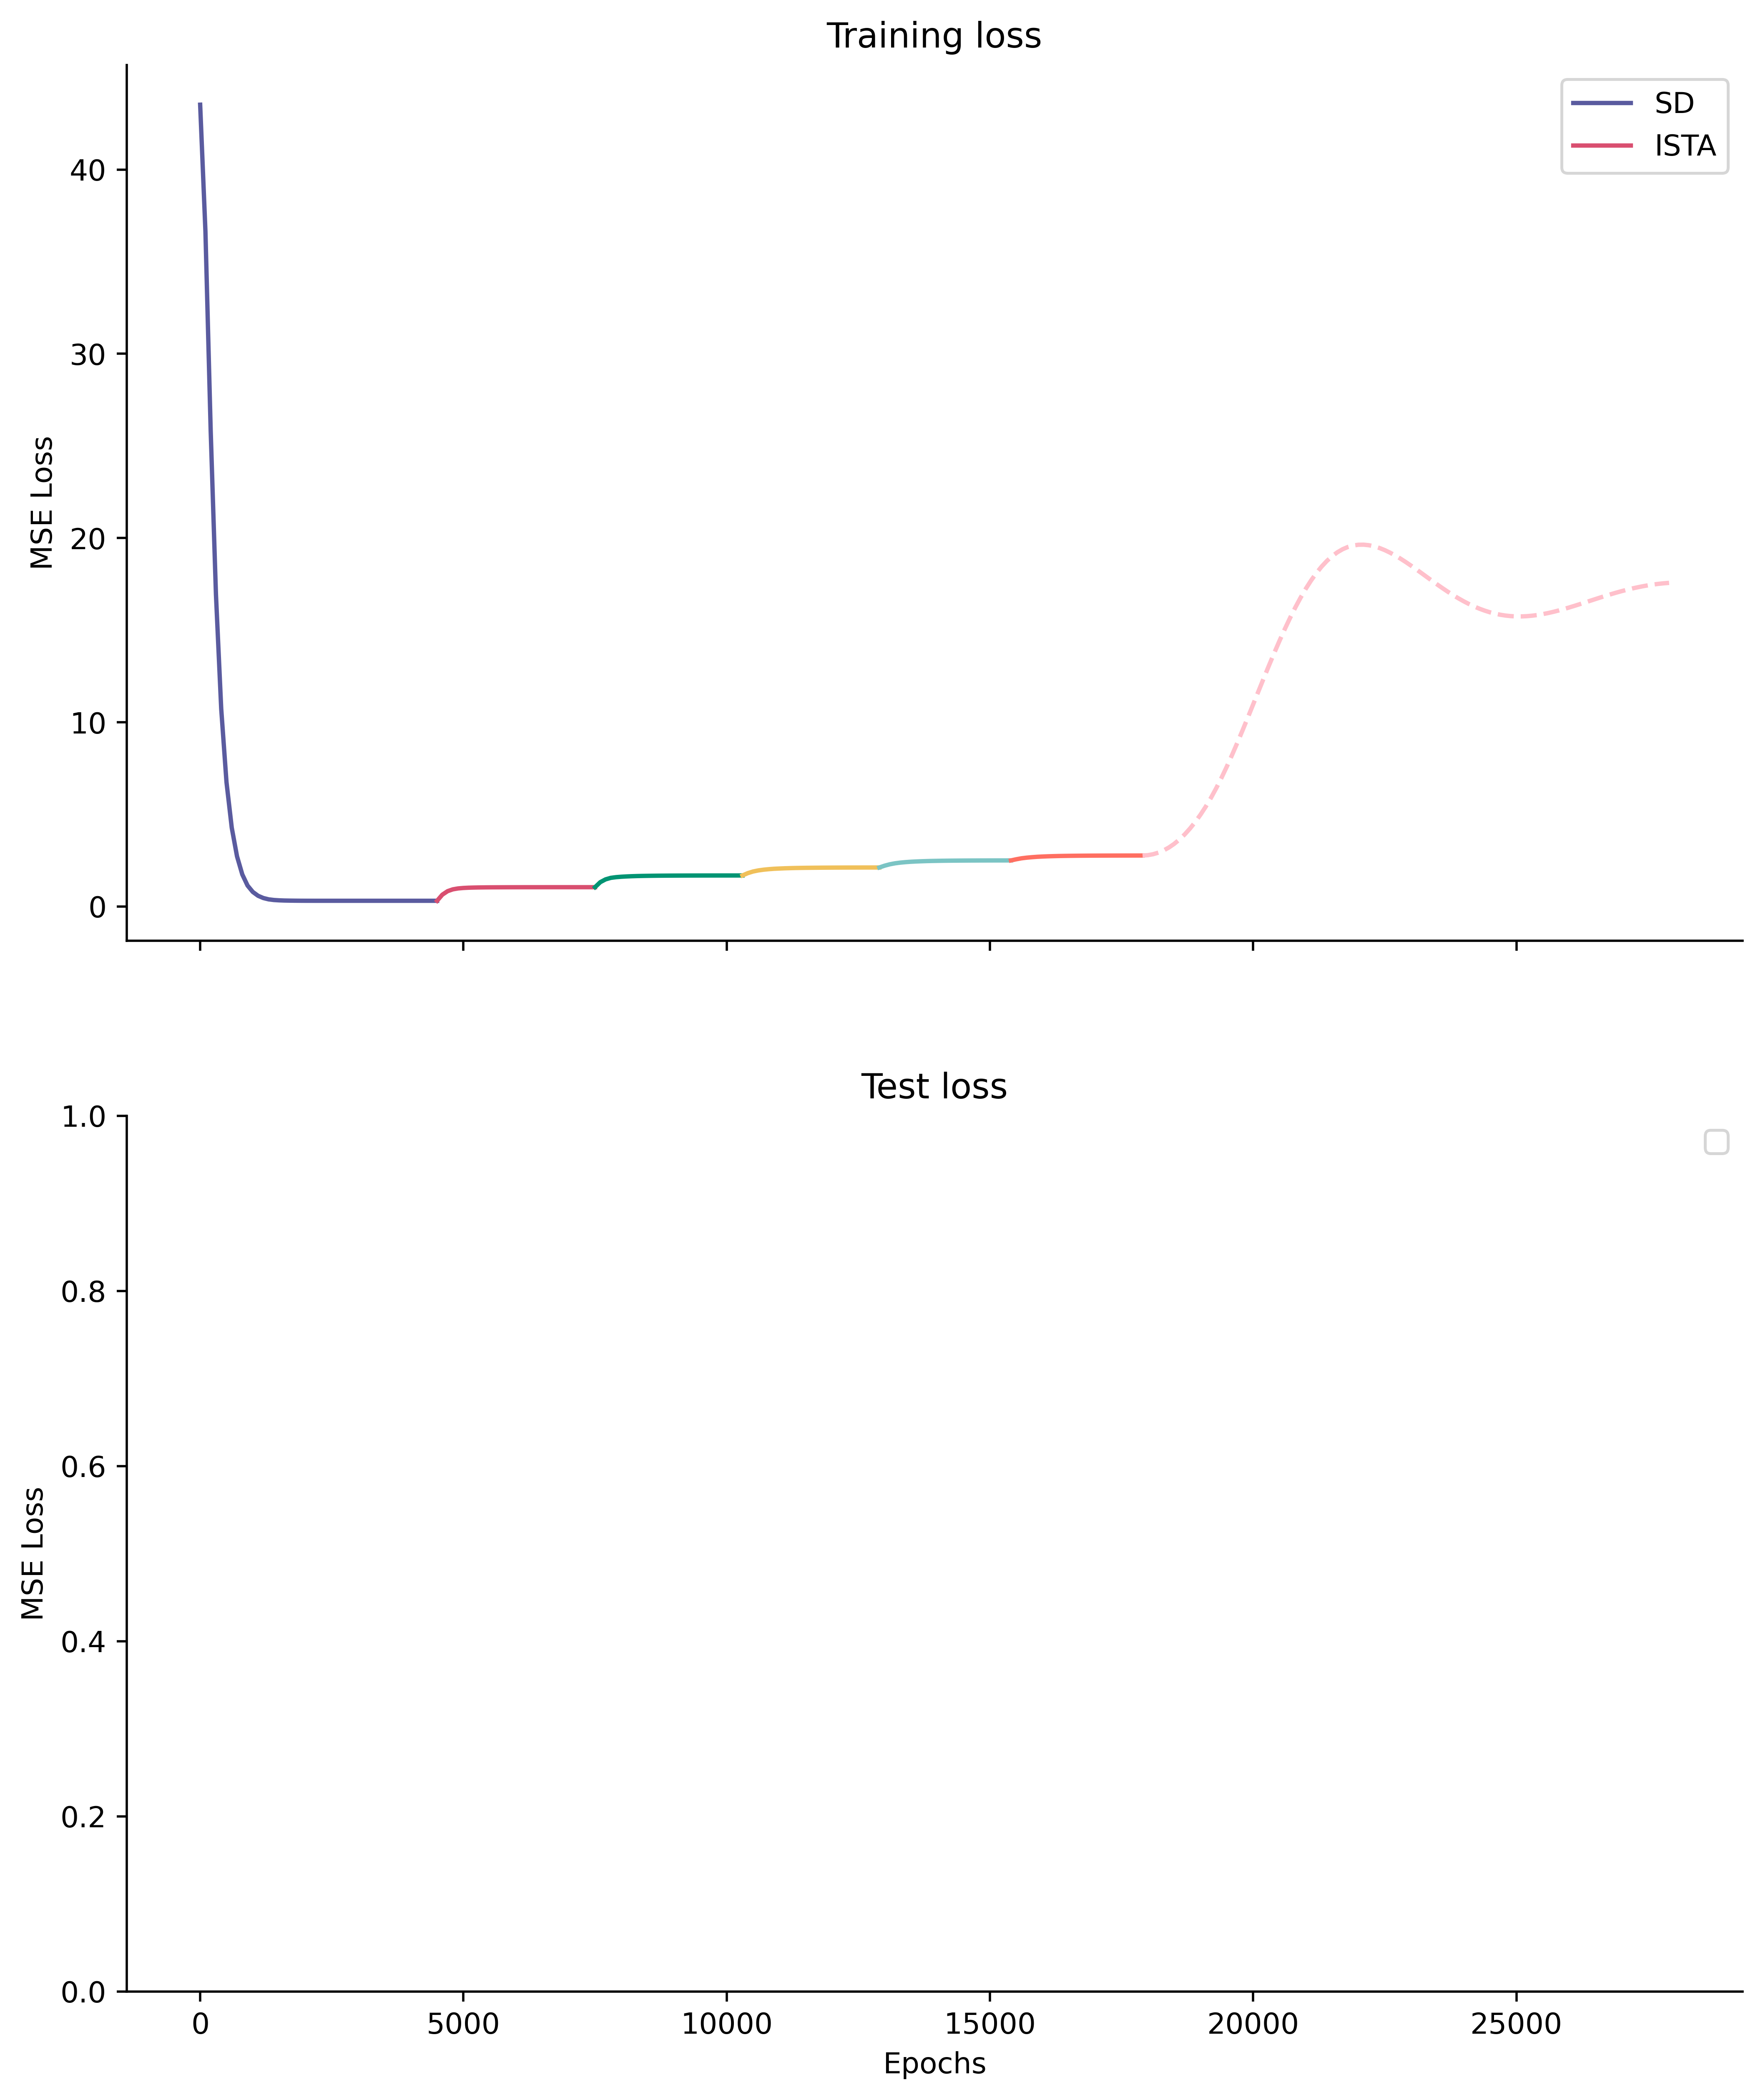

In [11]:
model_without_ista.plot_learning_curve()

## Warm start phase transition analysis

In [ ]:
pesr_history = {i: [] for i in range(1, 18)}
for j in range(1, 5):
    for i in range(1, 18):
        print(j, i)
        X_train = pd.read_csv(f"dataSets{j}/s{i}/{i}-train-x.csv", header = None)
        y_train = pd.read_csv(f"dataSets{j}/s{i}/{i}-train-y.csv", header = None)

        X_test = pd.read_csv(f"dataSets{j}/s{i}/{i}-test-x.csv", header = None)
        y_test = pd.read_csv(f"dataSets{j}/s{i}/{i}-test-y.csv", header = None)

        features = pd.read_csv(f"dataSets{j}/s{i}/{i}-important_inds.csv")
        features = features.values.flatten()

        model = an.AnnLasso(name="test", mode="regression", warm_start=False)
        model.fit(X_train, y_train, print_epochs=False, graph=False)
        pesr_history[i].append(model.results_analysis(X_test, y_test, features)['exact_recovery'])

In [ ]:
pesr_history2 = {i: [] for i in range(1, 18)}
for j in range(1, 5):
    for i in range(1, 18):
        print(j, i)
        X_train = pd.read_csv(f"dataSets{j}/s{i}/{i}-train-x.csv", header = None)
        y_train = pd.read_csv(f"dataSets{j}/s{i}/{i}-train-y.csv", header = None)

        X_test = pd.read_csv(f"dataSets{j}/s{i}/{i}-test-x.csv", header = None)
        y_test = pd.read_csv(f"dataSets{j}/s{i}/{i}-test-y.csv", header = None)

        features = pd.read_csv(f"dataSets{j}/s{i}/{i}-important_inds.csv")
        features = features.values.flatten()

        model = an.AnnLasso(name="test", mode="regression", warm_start=True)
        model.fit(X_train, y_train, print_epochs=False, graph=False)
        pesr_history2[i].append(model.results_analysis(X_test, y_test, features)['exact_recovery'])

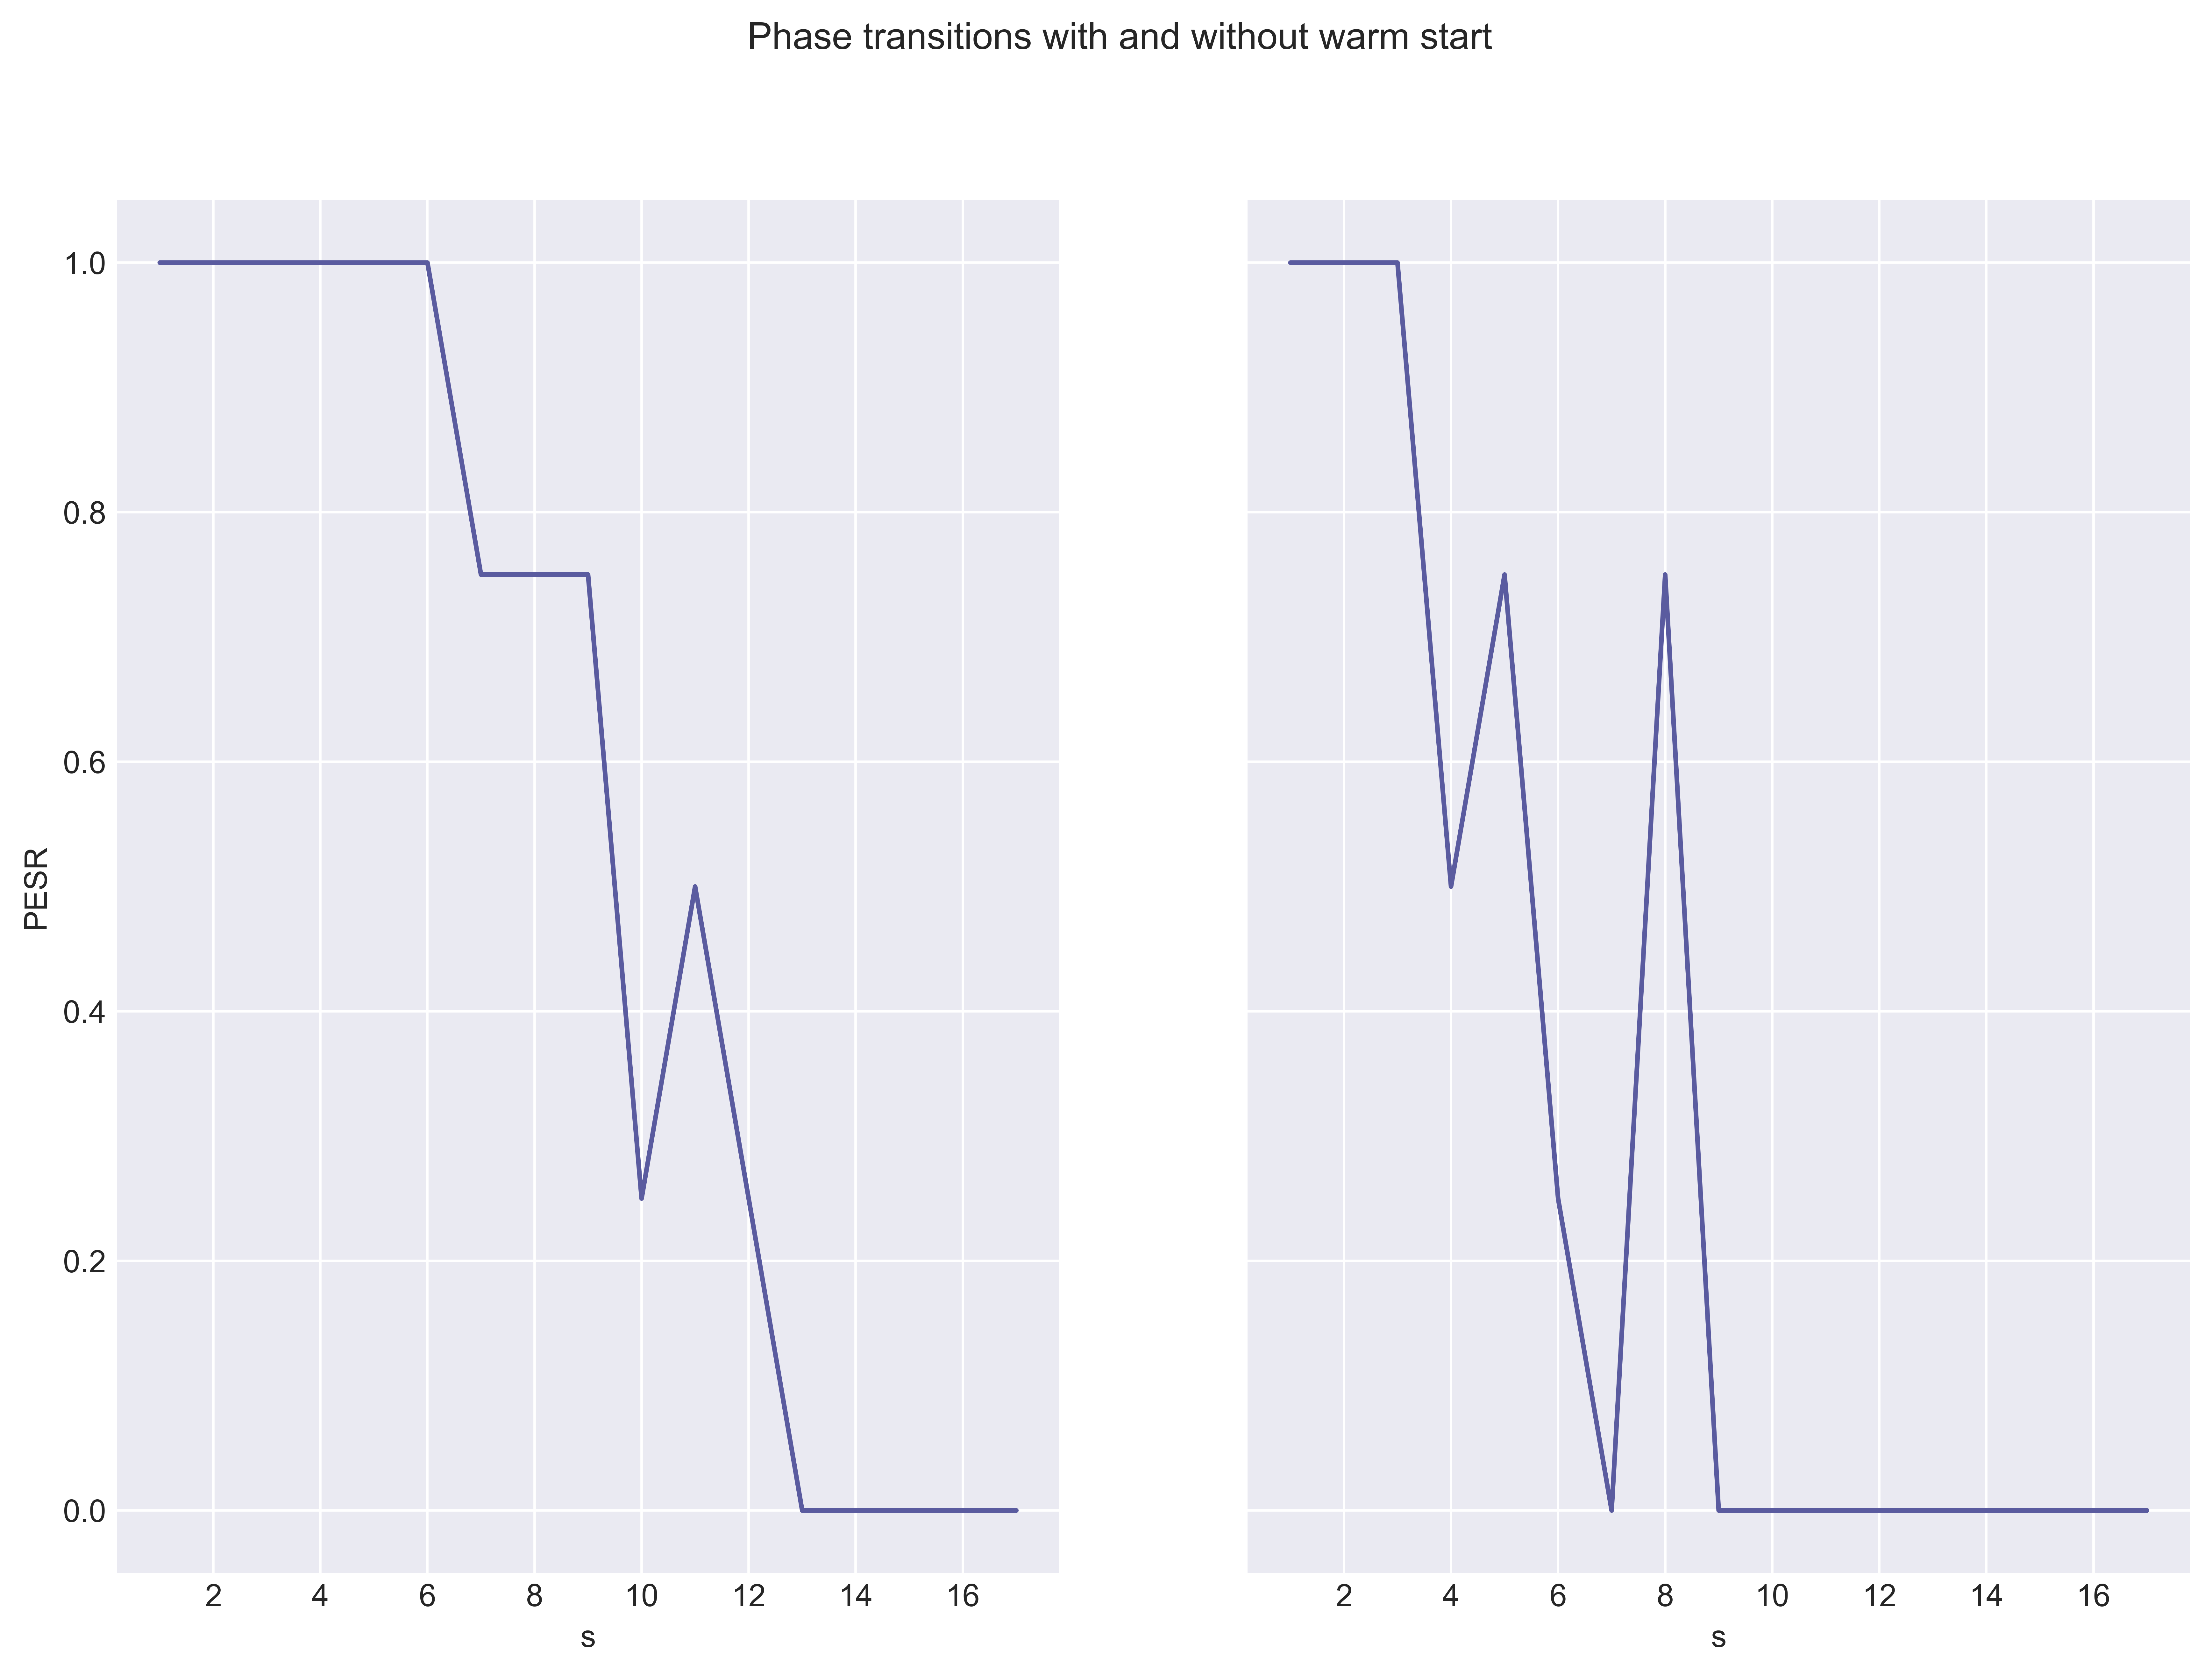

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, dpi=700, sharey=True)
fig.suptitle('Phase transitions with and without warm start')

ran = np.arange(1, 18)
mean_no_warm_start = [np.mean(pesr_history[i]) for i in ran]
mean_warm_start = [np.mean(pesr_history2[i]) for i in ran]

ax1.set_ylabel("PESR")
ax1.set_xlabel("s")
ax2.set_xlabel("s")
ax1.plot(ran, mean_warm_start)
ax2.plot(ran, mean_no_warm_start)

for ax in fig.get_axes():
    ax.label_outer()

plt.show()